In [1]:
import asyncio
import json
import logging
from logging import INFO
import os
from datetime import datetime, timezone, timedelta

from dotenv import load_dotenv

from graphiti_core import Graphiti
from graphiti_core.nodes import EpisodeType
from graphiti_core.search.search_config_recipes import NODE_HYBRID_SEARCH_RRF

In [2]:
logging.basicConfig(
    level=INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
logger = logging.getLogger(__name__)

load_dotenv()

neo4j_uri = os.environ.get('NEO4J_URI')
neo4j_user = os.environ.get('NEO4J_USERNAME')
neo4j_password = os.environ.get('NEO4J_PASSWORD')

if not neo4j_uri or not neo4j_user or not neo4j_password:
    raise ValueError('NEO4J_URI, NEO4J_USERNAME, and NEO4J_PASSWORD must be set')

In [ ]:
graphiti = Graphiti(neo4j_uri, neo4j_user, neo4j_password)

# await graphiti.build_indices_and_constraints()

2025-12-28 09:26:29 - neo4j.notifications - INFO - Received notification from DBMS server: {severity: INFORMATION} {code: Neo.ClientNotification.Schema.IndexOrConstraintAlreadyExists} {category: SCHEMA} {title: `CREATE RANGE INDEX community_uuid IF NOT EXISTS FOR (e:Community) ON (e.uuid)` has no effect.} {description: `RANGE INDEX community_uuid FOR (e:Community) ON (e.uuid)` already exists.} {position: None} for query: 'CREATE INDEX community_uuid IF NOT EXISTS FOR (n:Community) ON (n.uuid)'
2025-12-28 09:26:29 - neo4j.notifications - INFO - Received notification from DBMS server: {severity: INFORMATION} {code: Neo.ClientNotification.Schema.IndexOrConstraintAlreadyExists} {category: SCHEMA} {title: `CREATE RANGE INDEX entity_group_id IF NOT EXISTS FOR (e:Entity) ON (e.group_id)` has no effect.} {description: `RANGE INDEX entity_group_id FOR (e:Entity) ON (e.group_id)` already exists.} {position: None} for query: 'CREATE INDEX entity_group_id IF NOT EXISTS FOR (n:Entity) ON (n.group_i

In [10]:
episodes = [
    {
        'name': 'OpenAI',
        'content': {
            'name': 'OpenAI',
            'founded': '2015-12-8',
            'founders': 'Sam Altman',
            'type': 'AI 연구 개발 기업',
            'official_website': 'https://openai.com/'
        },
        'type': EpisodeType.json,
        'description': 'article metadata',
    },
    {
        'name': 'OpenAI의 기본 모델',
        'content': '2024년 5월 기준, OpenAI의 기본 모델은 GPT-4o입니다.',
        'type': EpisodeType.text,
        'description': 'news article',
    }
]

print(f'총 {len(episodes)}개의 에피소드가 정의되었습니다.')

총 2개의 에피소드가 정의되었습니다.


In [12]:
for i, episode in enumerate(episodes):
    await graphiti.add_episode(
        name=episode['name'],
        episode_body=episode['content']
        if isinstance(episode['content'], str)
        else json.dumps(episode['content']),
        source=episode['type'],
        source_description=episode['description'],
        reference_time=datetime.now(timezone.utc),
    )
    print(f"Added episode: {episode['name']} ({episode['type'].value})")

2025-12-27 15:30:05 - neo4j.notifications - WARNING - Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: entity_edges)} {position: line: 17, column: 7, offset: 473} for query: '\n                                    MATCH (e:Episodic)\n                                    WHERE e.valid_at <= $reference_time\n                                    \nAND e.group_id IN $group_ids\nAND e.source = $source\n        RETURN\n        \n    e.uuid AS uuid,\n    e.name AS name,\n    e.group_id AS group_id,\n    e.created_at AS created_at,\n    e.source AS source,\n    e.source_description AS source_description,\n    e.

Added episode: OpenAI (json)


2025-12-27 15:30:30 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-27 15:30:30 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 15:30:31 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 15:30:32 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-27 15:30:36 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-27 15:30:36 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 15:30:38 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 15:30:38 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 15:30:39 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-

Added episode: OpenAI의 기본 모델 (text)


In [14]:
episodes = [
    {
        'name': '새로운 모델 출시',
        'content': 'OpenAI의 현재 기본 모델은 8월 8일부로 GPT-5로 변경되었습니다.'
        'GPT-5는 전반적으로 훨씬 더 스마트하며, 특히 수학, 코딩, 시각적 인식, 의료 분야의 학술적 및 인간 평가 벤치마크에서의 성과에서 확인할 수 있습니다.'
        '수학(도구 없이 AIME 2025에서 94.6%), 실제 코딩(SWEBench에서 74.9%, 에이더 플리글롯에서 88%), 멀티모달 이해(MMU에서 84.2%), 의료(HealthBench Hard에서 46.2%) 전반에서 새롭게 최고 기록을 세웠으며 이러한 이점은 일상 사용에도 적용됩니다.',
        'type': EpisodeType.text,
        'description': 'news article',
    }
]

print(f"총 {len(episodes)} 개의 에피소드가 정의되었습니다.")

총 1 개의 에피소드가 정의되었습니다.


In [15]:
for i, episode in enumerate(episodes):
    await graphiti.add_episode(
        name=episode['name'],
        episode_body = episode['content']
        if isinstance(episode['content'], str)
        else json.dumps(episode['content']),
        source=episode['type'],
        source_description=episode['description'],
        reference_time=datetime.now(timezone.utc),
    )
    print(f'Added episode: {episode["name"]} ({episode["type"].value})')

2025-12-27 19:12:50 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-27 19:12:51 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 19:12:51 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 19:12:51 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 19:12:52 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 19:12:52 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 19:12:52 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 19:12:52 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-27 19:12:57 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
202

Added episode: 새로운 모델 출시 (text)


In [4]:
query = 'OpenAI의 정보를 알려주세요.'
print(f'검색 중: "{query}"')
results = await graphiti.search(query)

print('\n검색 결과:')
for result in results:
    print(f'UUID: {result.uuid}')
    print(f'Fact: {result.fact}')
    if hasattr(result, 'valid_at') and result.valid_at:
        print(f'Valid from: {result.valid_at}')
    if hasattr(result, 'invalid_at') and result.invalid_at:
        print(f'Valid until: {result.invalid_at}')
    print('---')

검색 중: "OpenAI의 정보를 알려주세요."


2025-12-28 09:28:46 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"



검색 결과:
UUID: a36f4fa8-b0c0-43af-bf1c-7c3bcbdf88cc
Fact: OpenAI is an AI 연구 개발 기업
Valid from: 2025-12-27 06:30:05+00:00
---
UUID: 78c979fb-e39c-4e40-822a-fc122a9cb500
Fact: OpenAI's official website is https://openai.com/
Valid from: 2025-12-27 06:30:05+00:00
---
UUID: 8a6dec10-3e6b-44bd-9176-59eeee941be8
Fact: OpenAI was founded by Sam Altman
Valid from: 2015-12-08 00:00:00+00:00
---
UUID: d1d9a8ad-6c1e-4ed6-8b8a-209be67e526f
Fact: As of May 2024, OpenAI's default model is GPT-4o.
Valid from: 2024-05-01 00:00:00+00:00
Valid until: 2025-08-08 00:00:00+00:00
---
UUID: 6468aa7c-7122-441f-a60d-ea24a03e7ae2
Fact: As of August 8, 2025, GPT-5 became the current default model of OpenAI.
Valid from: 2025-08-08 00:00:00+00:00
---
UUID: e3886294-bf54-4397-844f-d87808c94ed2
Fact: GPT-5 achieved the highest record in practical coding on 에이더 플리글롯 with a score of 88%.
---


In [5]:
query = 'OpenAI의 정보를 알려주세요.'

center_node_uuid = results[0].source_node_uuid

print('\n그래프 거리를 기반으로 검색 결과 재정렬:')
print(f'중심 노드 UUID 사용: {center_node_uuid}')

reranked_results = await graphiti.search(
    query, center_node_uuid=center_node_uuid
)

print('\n재정렬된 검색 결과:')
for result in reranked_results:
    print(f'UUID: {result.uuid}')
    print(f'Fact: {result.fact}')
    if hasattr(result, 'valid_at') and result.valid_at:
        print(f'Valid from: {result.valid_at}')
    if hasattr(result, 'invalid_at') and result.invalid_at:
        print(f'Valid until: {result.invalid_at}')
    print('---')


그래프 거리를 기반으로 검색 결과 재정렬:
중심 노드 UUID 사용: 7f85c485-91a1-47a1-918c-7cbc932e2174


2025-12-28 10:15:14 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"



재정렬된 검색 결과:
UUID: a36f4fa8-b0c0-43af-bf1c-7c3bcbdf88cc
Fact: OpenAI is an AI 연구 개발 기업
Valid from: 2025-12-27 06:30:05+00:00
---
UUID: 78c979fb-e39c-4e40-822a-fc122a9cb500
Fact: OpenAI's official website is https://openai.com/
Valid from: 2025-12-27 06:30:05+00:00
---
UUID: 8a6dec10-3e6b-44bd-9176-59eeee941be8
Fact: OpenAI was founded by Sam Altman
Valid from: 2015-12-08 00:00:00+00:00
---
UUID: d1d9a8ad-6c1e-4ed6-8b8a-209be67e526f
Fact: As of May 2024, OpenAI's default model is GPT-4o.
Valid from: 2024-05-01 00:00:00+00:00
Valid until: 2025-08-08 00:00:00+00:00
---
UUID: 6468aa7c-7122-441f-a60d-ea24a03e7ae2
Fact: As of August 8, 2025, GPT-5 became the current default model of OpenAI.
Valid from: 2025-08-08 00:00:00+00:00
---
UUID: e3886294-bf54-4397-844f-d87808c94ed2
Fact: GPT-5 achieved the highest record in practical coding on 에이더 플리글롯 with a score of 88%.
---


In [6]:
node_search_config = NODE_HYBRID_SEARCH_RRF.model_copy(deep=True)
node_search_config.limit = 5

node_search_results = await graphiti._search(
    query='gpt-5',
    config=node_search_config,
)

print('\n노드 검색 결과:')
for node in node_search_results.nodes:
    print(f'Node UUID: {node.uuid}')
    print(f'Node Name: {node.name}')
    node_summary = node.summary[:100] + '...' if len(node.summary) > 100 else node.summary
    print(f'Content Summary: {node_summary}')
    print(f'Node Labels: {", ".join(node.labels)}')
    print(f'Created At: {node.created_at}')
    if hasattr(node, 'attributes') and node.attributes:
        print('Attributes:')
        for key, value in node.attributes.items():
            print(f'   {key}: {value}')
    print('---')

2025-12-28 10:23:14 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"



노드 검색 결과:
Node UUID: dc13c5c9-d179-4f2d-b672-da45148298dc
Node Name: GPT-5
Content Summary: OpenAI의 기본 모델은 8월 8일 GPT-5로 변경되었으며, 수학, 코딩, 멀티모달 이해, 의료 분야에서 최고 성과를 기록하는 더욱 스마트한 모델입니다.
Node Labels: Entity
Created At: 2025-12-27 10:12:51.070896+00:00
---
Node UUID: 6f0ea52b-165d-4710-b8dd-54d94af210b4
Node Name: GPT-4o
Content Summary: OpenAI's default model as of May 2024 is GPT-4o.
Node Labels: Entity
Created At: 2025-12-27 06:30:30.217377+00:00
---
Node UUID: 253e5931-6803-42b6-ac3b-b901ae60c5d7
Node Name: AIME 2025
Content Summary: AIME 2025 is a math competition for which GPT-5 achieved a 94.6% score without tools.
Node Labels: Entity
Created At: 2025-12-27 10:12:51.070896+00:00
---
Node UUID: 81eee125-7ebe-4cca-94a0-bbd4921ebe15
Node Name: MMU
Content Summary: OpenAI의 GPT-5는 2024년 8월 8일에 기본 모델로 교체되어 수학, 코딩, 시각적 인식, 의료 분야에서 최고 성과를 기록하며, 멀티모달 이해 능력을 갖추고 있다.
Node Labels: Entity
Created At: 2025-12-27 10:12:51.070896+00:00
---
Node UUID: eda300c4-bc9b-484e-a6ec-37b8aef5e0b8
Node Name: SWE

In [7]:
from langchain_core.messages import AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode

In [8]:
llm = ChatOpenAI(model='gpt-4o', temperature=0)

In [9]:
@tool
async def save_episode(
    name: str,
    content: str,
    episode_type: str='text',
    description: str='User conversation episode'
) -> str:
    '''
    사용자가 제공한 정보를 저장합니다. 정보가 특정 시점에 한정된다면 시간 정보를 함께 저장해야 합니다.

    Args:
        name (str): 에피소드의 이름 또는 제목
        content (str): 에피소드의 내용 (텍스트 또는 JSON 문자열)
        episode_type (str): 에피소드 타입 ('text', 'json', 'message' 중 하나, 기본값: 'text)
        description (str): 에피소드에 대한 설명 (기본값: 'User conversation episode')
    
    Returns:
        str: 저장 결과 메시지
    '''
    try:
        episode_type_map = {
            'text': EpisodeType.text,
            'json': EpisodeType.json,
            'message': EpisodeType.message
        }

        ep_type = episode_type_map.get(episode_type.lower(), EpisodeType.text)

        await graphiti.add_episode(
            name=name,
            episode_body=content,
            source=ep_type,
            source_description=description,
            reference_time=datetime.now(timezone.utc),
        )

        return f'에피소드 "{name}"이 성공적으로 저장되었습니다. (타입: {episode_type})'

    except Exception as e:
        return f'에피소드 저장 중 오류가 발생했습니다: {str(e)}'

In [ ]:
tools = [save_episode]
llm_with_tools = llm.bind_tools(tools)

In [13]:
query = '''
아래 내용 저장해주세요.

네이버가 인공지능(AI) 기술을 적용한 새로운 '맞춤형 검색'을 도입했다.
이용자의 기존 검색 이력을 보여주는 대신 AI 추천 검색어와 숏폼 콘텐츠를 띄우는 식이다.
카카오도 다음달 AI가 접목된 카카오톡 개편 방향을 공개할 예정이어서 두 대형 플랫폼의 AI 서비스 경쟁이 본격화하고 있다.
'''
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(llm, tools)
result = await agent.ainvoke({'messages': [('user', query)]})

<ipython-input-13-8afe4d42029c>:10: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools)
2025-12-28 10:54:38 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-12-28 10:54:43 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 10:54:44 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 10:54:44 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 10:54:44 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 10:54:44 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 10:54:45 - httpx - INFO - HTT

In [14]:
def edges_to_facts_string(edges):
    '''
    엣지 검색 결과를 문자열로 변환하는 헬퍼 함수
    '''
    if not edges:
        return "관련 정보를 찾을 수 없습니다."
    
    current_time = datetime.now(timezone.utc)

    def is_expired(edge):
        if not (hasattr(edge, 'invalid_at') and edge.invalid_at):
            return False
        try:
            invalid_time = edge.invalid_at
            if isinstance(invalid_time, str):
                invalid_time = datetime.fromisoformat(invalid_time.replace('Z', '+00:00'))
            if invalid_time.tzinfo is None:
                invalid_time = invalid_time.replace(tzinfo=timezone.utc)
            return current_time > invalid_time
        except:
            return False
        
    def get_fact_content(edge):
        return edge.fact if hasattr(edge, 'fact') and edge.fact else str(edge)
    
    valid_facts = [get_fact_content(edge) for edge in edges if not is_expired(edge)]
    expired_count = len(edges) - len(valid_facts)

    if not valid_facts:
        return f"관련 정보가 있었지만 모두 만료되었습니다. (만료된 정보 {expired_count}개)" if expired_count else "관련 정보를 찾을 수 없습니다."

    result = '=== 현재 유효한 정보 ===\n' + '\n'.join(valid_facts)
    if expired_count:
        result += f"\n\n[필터링 정보: 유효 {len(valid_facts)}개, 만료 {expired_count}개 제외됨]"
    
    return result

In [15]:
@tool
async def get_memory(
    query: str,
) -> str:
    '''
    사용자와의 대화 기록이나 저장된 정보를 검색하여 질문에 답할 때 사용합니다. (만료된 정보 필터링 포함)
    
    Args:
        query (str): 검색할 쿼리
    
    Returns:
        str: 검색 결과 (유효한 정보만 또는 모든 정보)
    '''
    try:
        edge_results = await graphiti.search(
            query,
            num_results=5
        )

        return edges_to_facts_string(edge_results)
    except Exception as e:
        return f"정보 검색 중 오류가 발생했습니다: {str(e)}"

In [16]:
tools = [get_memory]
llm_with_tools = llm.bind_tools(tools)

In [17]:
query = '''
OpenAI의 현재 정보를 알려주세요.
'''
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(llm, tools)
result = await agent.ainvoke({'messages': [('user', query)]})

<ipython-input-17-3ca3f523e59f>:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools)
2025-12-28 11:21:37 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-12-28 11:21:39 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 11:21:41 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [18]:
result

{'messages': [HumanMessage(content='\nOpenAI의 현재 정보를 알려주세요.\n', additional_kwargs={}, response_metadata={}, id='d4a5e78e-d7ef-4dbf-8760-32dfbb899106'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 106, 'total_tokens': 124, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrahcWSrrYhc3s4uUh2yO55bFWxKf', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b62c2-df3a-7ba0-9240-a98a16f74bba-0', tool_calls=[{'name': 'get_memory', 'args': {'query': 'OpenAI의 현재 정보'}, 'id': 'call_02VVScM1kS38awWtKJLZ3ctU', 'type': 'tool_call'}], usage_metadata={'input_tokens': 106, 'output_tokens': 18, 'total_

In [21]:
print(result['messages'][2].content)

=== 현재 유효한 정보 ===
OpenAI's official website is https://openai.com/
OpenAI was founded by Sam Altman
As of August 8, 2025, GPT-5 became the current default model of OpenAI.

[필터링 정보: 유효 3개, 만료 2개 제외됨]


In [22]:
import uuid
from typing_extensions import TypedDict
from typing import Annotated

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, add_messages

In [23]:
tools = [save_episode, get_memory]
tool_node = ToolNode(tools)

In [24]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    llm,
    tools,
    prompt='''
    당신은 최신 정보를 저장하고 이를 기반으로 답변하는 지능형 에이전트입니다.
    사용자가 입력한 정보를 저장하거나, 저장된 최신 정보를 기반으로 사용자의 질문에 정확하고 도움이 되는 답변을 제공해야 합니다.

    답변 시 유의사항:
    - 간결하고 명확하게 답변하세요.
    - 저장된 정보가 부족하거나 날짜에 관한 추가 정보가 필요하다면 사용자에게 다시 물어보세요.
    - 최신 정보를 우선적으로 활용하여 답변하세요.    
    '''
)

<ipython-input-24-abe3f8a31710>:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


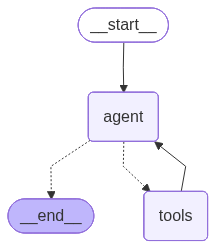

In [25]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [26]:
query = '''
아래 내용 저장해줘.

최근 2형 당뇨병이 청소년, 중년 등 나이와 관계 없이 급격히 늘고 있다. 탄수화물 과다 섭취, 운동 부족 등 나쁜 생활

최근 청소년도 2형 당뇨병 급속 증가...비만, 과체중이 위험요인

주로 비만, 과체중과 관련이 있는 2형 당뇨병의 유병률(당뇨병 인구의 비율)이 급속히 늘고 있다.
30세 미만 젊은이들도 예외가 아니다. 최근 국제 학술지 <대한의학회지(JKMS)>에 30세 미만의
2형 당뇨병 유병률이 2021년 인구 10만 명당 270.4명으로 2008년에 비해 3.7배 늘었다는 논문이
실렸다. 과거 소아, 청소년은 1형 당뇨병이 주로 발생했으나 최근 청소년과 젊은 성인에서 2형 당뇨병
환자가 빠르게 늘고 있다. 식습관, 운동 부족 등 나쁜 생활 습관이 원인으로 보인다.
'''

result = await agent.ainvoke(
    {
        'messages': [
            {
                'role': 'user',
                'content': query,
            }
        ]
    },
    config={'configurable': {'thread_id': uuid.uuid4().hex}}
)

2025-12-28 15:55:05 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-12-28 15:55:09 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 15:55:10 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 15:55:10 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 15:55:10 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 15:55:10 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 15:55:11 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 15:55:11 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 15:55:11 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 

In [27]:
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================


아래 내용 저장해줘.

최근 2형 당뇨병이 청소년, 중년 등 나이와 관계 없이 급격히 늘고 있다. 탄수화물 과다 섭취, 운동 부족 등 나쁜 생활

최근 청소년도 2형 당뇨병 급속 증가...비만, 과체중이 위험요인

주로 비만, 과체중과 관련이 있는 2형 당뇨병의 유병률(당뇨병 인구의 비율)이 급속히 늘고 있다.
30세 미만 젊은이들도 예외가 아니다. 최근 국제 학술지 <대한의학회지(JKMS)>에 30세 미만의
2형 당뇨병 유병률이 2021년 인구 10만 명당 270.4명으로 2008년에 비해 3.7배 늘었다는 논문이
실렸다. 과거 소아, 청소년은 1형 당뇨병이 주로 발생했으나 최근 청소년과 젊은 성인에서 2형 당뇨병
환자가 빠르게 늘고 있다. 식습관, 운동 부족 등 나쁜 생활 습관이 원인으로 보인다.

================================== Ai Message ==================================
Tool Calls:
  save_episode (call_AdQHWEbh3w3hXr2J0MaKiBEy)
 Call ID: call_AdQHWEbh3w3hXr2J0MaKiBEy
  Args:
    name: 2형 당뇨병 증가 추세
    content: 최근 2형 당뇨병이 청소년, 중년 등 나이와 관계 없이 급격히 늘고 있다. 탄수화물 과다 섭취, 운동 부족 등 나쁜 생활

최근 청소년도 2형 당뇨병 급속 증가...비만, 과체중이 위험요인

주로 비만, 과체중과 관련이 있는 2형 당뇨병의 유병률(당뇨병 인구의 비율)이 급속히 늘고 있다. 30세 미만 젊은이들도 예외가 아니다. 최근 국제 학술지 <대한의학회지(JKMS)>에 30세 미만의 2형 당뇨병 유병률이 2021년 인구 10만 명당 270.4명으로 2008년에 비해 3.7배 늘었다는 논문이 실렸다. 과거 소아, 청소년은

In [28]:
query = '''
2형 당뇨병의 원인을 찾아서 알려주세요.
'''

result = await agent.ainvoke(
    {
        'messages': [
            {
                'role': 'user',
                'content': query,
            }
        ]
    },
    config={'configurable': {'thread_id': uuid.uuid4().hex}}
)

2025-12-28 15:57:18 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-12-28 15:57:19 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 15:57:21 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [29]:
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================


2형 당뇨병의 원인을 찾아서 알려주세요.

================================== Ai Message ==================================
Tool Calls:
  get_memory (call_zthDt87LbwuTl97uqtDVgqWJ)
 Call ID: call_zthDt87LbwuTl97uqtDVgqWJ
  Args:
    query: 2형 당뇨병의 원인
================================= Tool Message =================================
Name: get_memory

=== 현재 유효한 정보 ===
운동 부족은 2형 당뇨병 증가의 원인 중 하나이다.
비만은 2형 당뇨병의 위험 요인이다.
과체중은 2형 당뇨병의 위험 요인이다.
탄수화물 과다 섭취는 2형 당뇨병 증가의 원인 중 하나이다.
2형 당뇨병 유병률이 젊은 성인 사이에서 빠르게 늘고 있다.
================================== Ai Message ==================================

2형 당뇨병의 원인으로는 다음과 같은 요인들이 있습니다:

1. **운동 부족**: 신체 활동이 부족하면 2형 당뇨병의 위험이 증가할 수 있습니다.
2. **비만**: 체중이 많이 나가는 것은 2형 당뇨병의 주요 위험 요인 중 하나입니다.
3. **과체중**: 비만까지는 아니더라도 과체중 상태도 위험 요인으로 작용할 수 있습니다.
4. **탄수화물 과다 섭취**: 탄수화물을 과도하게 섭취하는 것도 2형 당뇨병의 원인 중 하나입니다.

이 외에도 유전적 요인이나 기타 생활 습관 등이 영향을 미칠 수 있습니다.


In [30]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    user_name: str
    user_node_uuid: str

In [31]:
tools = [save_episode, get_memory]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

In [32]:
async def chatbot(state: State):
    facts_string = None
    if len(state['messages']) > 0:
        last_message = state['messages'][-1]
        print(f"last_message: {last_message}")
        graphiti_query = f'{"AI" if isinstance(last_message, AIMessage) else state["user_name"]}: {last_message.content}'
        print(f'graphiti_query: {graphiti_query}')
        edge_results = await graphiti.search(
            graphiti_query,
            center_node_uuid=state['user_node_uuid'],
            num_results=5
        )
        print('edge_results', edge_results)
        facts_string = edges_to_facts_string(edge_results)
        print(f"facts_string: {facts_string}")
    
    system_message = SystemMessage(
        content=f'''당신은 최신 정보를 저장하고 이를 기반으로 답변하는 지능형 에이전트입니다.
        사용자가 입력한 정보를 저장하거나, 저장된 최신 정보를 기반으로 사용자의 질문에 정확하고 도움이 되는 답변을 제공해야 합니다.
        특히 사용자의 메모리에 담긴 취향이나 정보를 검색해서 적절한 답변을 할 수 있습니다.

        사용 가능한 도구:
        - save_episode: 사용자가 제공한 정보를 저장합니다. 정보가 특정 시점에 한정된다면 시간 정보를 함께 저장해야 합니다.
        - get_memory: 사용자와의 대화 기록이나 저장된 정보를 검색하여 질문에 답할 때 사용합니다.

        답변 시 유의사항:
        - 간결하고 명확하게 답변하세요.
        - 저장된 정보가 부족하거나 추가 정보가 필요하다면 사용자에게 다시 물어보세요.
        - 최신 정보를 우선적으로 활용하여 답변하세요.

        사용자 관련 정보 및 대화 기록:
        {facts_string}
        '''
    )

    messages = [system_message] + state['messages']

    response = await llm_with_tools.ainvoke(messages)

    if not response.tool_calls:
        asyncio.create_task(
            graphiti.add_episode(
                name='Chatbot Response',
                episode_body=f'{state["user_name"]}: {state["messages"][0]}\nAI: {response.content}',
                source=EpisodeType.message,
                reference_time=datetime.now(timezone.utc),
                source_description='Chatbot'
            )
        )
    
    print('response', response)
    print()
    return {'messages': [response]}

In [33]:
async def should_continue(state, config):
    messages = state['messages']
    last_message = messages[-1]
    if not last_message.tool_calls:
        return 'end'
    else:
        return 'continue'

In [34]:
graph_builder = StateGraph(State)
memory = MemorySaver()

graph_builder.add_node('agent', chatbot)
graph_builder.add_node('tools', tool_node)

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges('agent', should_continue, {'continue': 'tools', 'end': END})
graph_builder.add_edge('tools', 'agent')

graph = graph_builder.compile(checkpointer=memory)

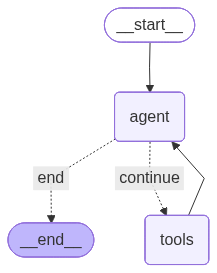

In [35]:
graph

In [36]:
history = [
    {
        'messages': '''
            nayeon: 얼마 전에 좀비딸 영화 봤는데 재밌더라. 그게 웹툰도 재밌었거든.
            AI: 오, 좀비딸 영화와 웹툰이라니 흥미롭네요! 좀비딸 웹툰은 어떤 점이 특히 재미있었나요?
        '''
    },
    {
        'messages': '''
            nayeon: 내가 원래 재난 영화를 좋아하는데, 이건 코미디도 섞여서 더 재미있었어.
            AI: 재난 영화에 코미디 요소가 더해지면 긴장감도 풀리고 재미가 배가되죠. 혹시 영화에서 가장 기억에 남는 장면이 있었나요?
        '''
    }
]

for chat in history:
    await graphiti.add_episode(
        name='Chatbot Response',
        episode_body=chat['messages'],
        source=EpisodeType.message,
        reference_time=datetime.now(timezone.utc),
        source_description='Chatbot',
    )

2025-12-28 16:18:59 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:19:00 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:19:00 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:19:00 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:19:00 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:19:04 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:19:09 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:19:09 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:19:10 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025

In [37]:
user_name = 'nayeon'
user_node_uuid = '9fbaf36a-1924-418f-89f3-479ab5b79350'

In [ ]:
result = await graph.ainvoke(
    {
        'messages': [
            {
                'role': 'user',
                'content': '떡볶이 먹고 장염 걸렸어ㅠㅠ 이제 안먹을래'
            }
        ],
        'user_name': user_name,
        'user_node_uuid': user_node_uuid,
    },
    config={'configurable': {'thread_id': uuid.uuid4().hex}}
)

last_message: content='떡볶이 먹고 장염 걸렸어ㅠㅠ 이제 안먹을래' additional_kwargs={} response_metadata={} id='27fb99e3-1686-4d0c-8d61-a18e05b5a757'
graphiti_query: nayeon: 떡볶이 먹고 장염 걸렸어ㅠㅠ 이제 안먹을래


2025-12-28 16:29:22 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


edge_results [EntityEdge(uuid='f7cc5065-73f7-41b3-b26d-5b1a3e1bc38c', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='aef067a9-0e22-4291-8d8b-961aa3832b00', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='FOUND_WEBTOON_INTERESTING', fact='nayeon found the 좀비딸 웹툰 interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3'], expired_at=None, valid_at=datetime.datetime(2025, 12, 28, 0, 0, tzinfo=<UTC>), invalid_at=None, attributes={}), EntityEdge(uuid='f95fa281-52a2-4102-b724-267865de74c8', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='acd3528e-6812-4c89-9dd2-0927a8116204', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='WATCHED_AND_FOUND_INTERESTING', fact='nayeon recently watched the 좀비딸 영화 and found it interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3'], expired_at=None, valid_at=date

2025-12-28 16:29:23 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


response content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 594, 'total_tokens': 655, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrfVSyvixkssj5mWOsxnq67K47GRj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019b63dc-a3f8-78f3-92b0-0021810459ec-0' tool_calls=[{'name': 'save_episode', 'args': {'name': '떡볶이 관련 경험', 'content': '떡볶이를 먹고 장염에 걸려서 이제 떡볶이를 먹지 않기로 함', 'description': 'User had a negative experience with 떡볶이'}, 'id': 'call_9bqhaiVNRx1D9dkG0uGjdldf', 'type': 'tool_call'}] usage_metadata={'input_tokens': 594, 'output_tokens': 61, 'total_tokens': 655, 'input_token_details': {'audio': 0, 'cache_r

...

2025-12-28 16:29:34 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


edge_results [EntityEdge(uuid='f7cc5065-73f7-41b3-b26d-5b1a3e1bc38c', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='aef067a9-0e22-4291-8d8b-961aa3832b00', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='FOUND_WEBTOON_INTERESTING', fact='nayeon found the 좀비딸 웹툰 interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3'], expired_at=None, valid_at=datetime.datetime(2025, 12, 28, 0, 0, tzinfo=<UTC>), invalid_at=None, attributes={}), EntityEdge(uuid='f95fa281-52a2-4102-b724-267865de74c8', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='acd3528e-6812-4c89-9dd2-0927a8116204', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='WATCHED_AND_FOUND_INTERESTING', fact='nayeon recently watched the 좀비딸 영화 and found it interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3'], expired_at=None, valid_at=date

2025-12-28 16:29:35 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


response content='떡볶이 때문에 안 좋은 경험을 하셨군요. 이제 떡볶이는 피하시는 게 좋겠네요. 다른 맛있는 음식을 찾아보는 것도 좋을 것 같아요!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 662, 'total_tokens': 707, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrfVezq2m1fOaV6zgmHu7Akmk95hK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019b63dc-d39d-7c61-b9f1-76b8e520a6c2-0' usage_metadata={'input_tokens': 662, 'output_tokens': 45, 'total_tokens': 707, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}



2025-12-28 16:29:37 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:29:37 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:29:37 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:29:37 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:29:39 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:29:41 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:29:42 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:29:42 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:29:42 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025

In [ ]:
result = await graph.ainvoke(
    {
        'messages': [
            {
                'role': 'user',
                'content': '니가 아는 내 정보 알려줘.'
            }
        ],
        'user_name': user_name,
        'user_node_uuid': user_node_uuid,
    },
    config={'configurable': {'thread_id': uuid.uuid4().hex}}
)

last_message: content='니가 아는 내 정보 알려줘.' additional_kwargs={} response_metadata={} id='e5a45545-76a3-4be2-bf4c-92f20b377609'
graphiti_query: nayeon: 니가 아는 내 정보 알려줘.


2025-12-28 16:30:23 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


edge_results [EntityEdge(uuid='f7cc5065-73f7-41b3-b26d-5b1a3e1bc38c', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='aef067a9-0e22-4291-8d8b-961aa3832b00', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='FOUND_WEBTOON_INTERESTING', fact='nayeon found the 좀비딸 웹툰 interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3'], expired_at=None, valid_at=datetime.datetime(2025, 12, 28, 0, 0, tzinfo=<UTC>), invalid_at=None, attributes={}), EntityEdge(uuid='f95fa281-52a2-4102-b724-267865de74c8', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='acd3528e-6812-4c89-9dd2-0927a8116204', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='WATCHED_AND_FOUND_INTERESTING', fact='nayeon recently watched the 좀비딸 영화 and found it interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3'], expired_at=None, valid_at=date

2025-12-28 16:30:24 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


response content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 544, 'total_tokens': 560, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrfWR4e2BSREGcitfjWeXkvoDnJ3y', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019b63dd-9194-78b2-a14e-7c864cdffb56-0' tool_calls=[{'name': 'get_memory', 'args': {'query': 'nayeon'}, 'id': 'call_IK4efDdZtbEDykaFL4SESYbw', 'type': 'tool_call'}] usage_metadata={'input_tokens': 544, 'output_tokens': 16, 'total_tokens': 560, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}



...

2025-12-28 16:30:25 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


edge_results [EntityEdge(uuid='f95fa281-52a2-4102-b724-267865de74c8', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='acd3528e-6812-4c89-9dd2-0927a8116204', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='WATCHED_AND_FOUND_INTERESTING', fact='nayeon recently watched the 좀비딸 영화 and found it interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3'], expired_at=None, valid_at=datetime.datetime(2025, 12, 28, 0, 0, tzinfo=<UTC>), invalid_at=None, attributes={}), EntityEdge(uuid='f7cc5065-73f7-41b3-b26d-5b1a3e1bc38c', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='aef067a9-0e22-4291-8d8b-961aa3832b00', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='FOUND_WEBTOON_INTERESTING', fact='nayeon found the 좀비딸 웹툰 interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3'], expired_at=None, valid_at=date

2025-12-28 16:30:26 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


response content='현재 저장된 정보에 따르면, 당신은 "좀비딸" 웹툰과 영화를 흥미롭게 보셨습니다. 다른 정보가 필요하시면 말씀해 주세요!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 612, 'total_tokens': 652, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrfWT1THlnVgKeHPl5pplQXBmK0nc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019b63dd-996d-76f2-8661-155341c19564-0' usage_metadata={'input_tokens': 612, 'output_tokens': 40, 'total_tokens': 652, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}



2025-12-28 16:30:27 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:30:28 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:30:28 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:30:28 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:30:30 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:30:32 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:30:32 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:30:32 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:30:33 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025

In [43]:
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

니가 아는 내 정보 알려줘.
================================== Ai Message ==================================
Tool Calls:
  get_memory (call_IK4efDdZtbEDykaFL4SESYbw)
 Call ID: call_IK4efDdZtbEDykaFL4SESYbw
  Args:
    query: nayeon
================================= Tool Message =================================
Name: get_memory

=== 현재 유효한 정보 ===
nayeon found the 좀비딸 웹툰 interesting
nayeon recently watched the 좀비딸 영화 and found it interesting
================================== Ai Message ==================================

현재 저장된 정보에 따르면, 당신은 "좀비딸" 웹툰과 영화를 흥미롭게 보셨습니다. 다른 정보가 필요하시면 말씀해 주세요!


In [ ]:
result = await graph.ainvoke(
    {
        'messages': [
            {
                'role': 'user',
                'content': '나 영화 추천 해줄 수 있어?'
            }
        ],
        'user_name': user_name,
        'user_node_uuid': user_node_uuid,
    },
    config={'configurable': {'thread_id': uuid.uuid4().hex}}
)

last_message: content='나 영화 추천 해줄 수 있어?' additional_kwargs={} response_metadata={} id='4b70d09e-f2ac-43ed-ac55-0ded4bff0002'
graphiti_query: nayeon: 나 영화 추천 해줄 수 있어?


2025-12-28 16:31:37 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


edge_results [EntityEdge(uuid='f95fa281-52a2-4102-b724-267865de74c8', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='acd3528e-6812-4c89-9dd2-0927a8116204', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='WATCHED_AND_FOUND_INTERESTING', fact='nayeon recently watched the 좀비딸 영화 and found it interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3', '361b8878-7fd7-41eb-a3e0-3fbb6f358c4f'], expired_at=None, valid_at=datetime.datetime(2025, 12, 28, 0, 0, tzinfo=<UTC>), invalid_at=None, attributes={}), EntityEdge(uuid='f7cc5065-73f7-41b3-b26d-5b1a3e1bc38c', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='aef067a9-0e22-4291-8d8b-961aa3832b00', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='FOUND_WEBTOON_INTERESTING', fact='nayeon found the 좀비딸 웹툰 interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d6

2025-12-28 16:31:38 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


response content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 530, 'total_tokens': 548, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrfXdRgOwceaBto8XXJiPvKcVC4se', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019b63de-b490-7f03-9bb1-7d85a9f7a63e-0' tool_calls=[{'name': 'get_memory', 'args': {'query': 'nayeon movie preference'}, 'id': 'call_2fjg2H3xWdUNg5F4UbLpI1KC', 'type': 'tool_call'}] usage_metadata={'input_tokens': 530, 'output_tokens': 18, 'total_tokens': 548, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}



...

2025-12-28 16:31:40 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


edge_results [EntityEdge(uuid='f95fa281-52a2-4102-b724-267865de74c8', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='acd3528e-6812-4c89-9dd2-0927a8116204', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='WATCHED_AND_FOUND_INTERESTING', fact='nayeon recently watched the 좀비딸 영화 and found it interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3', '361b8878-7fd7-41eb-a3e0-3fbb6f358c4f'], expired_at=None, valid_at=datetime.datetime(2025, 12, 28, 0, 0, tzinfo=<UTC>), invalid_at=None, attributes={}), EntityEdge(uuid='f7cc5065-73f7-41b3-b26d-5b1a3e1bc38c', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='aef067a9-0e22-4291-8d8b-961aa3832b00', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='FOUND_WEBTOON_INTERESTING', fact='nayeon found the 좀비딸 웹툰 interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d6

2025-12-28 16:31:41 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


response content='최근에 재미있게 본 영화로는 "좀비딸"이 있었고, 재난 영화에 코미디 요소가 들어간 것을 즐기는 것 같아요. 이런 취향을 고려해서 "Shaun of the Dead" 같은 좀비 코미디 영화를 추천드릴게요. 이 영화는 좀비 아포칼립스를 배경으로 하면서도 유머가 가득한 작품입니다. 즐겁게 감상하세요!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 624, 'total_tokens': 721, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrfXg6cpiwTgrWqar9aZO7ZJzXxSq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019b63de-bdb6-76e3-ae56-e5a23bca9911-0' usage_metadata={'input_tokens': 624, 'output_tokens': 97, 'total_tokens': 721, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}



2025-12-28 16:31:43 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:31:43 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:31:43 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:31:43 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:31:44 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:31:46 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:31:49 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:31:49 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:31:50 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025

In [45]:
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

나 영화 추천 해줄 수 있어?
================================== Ai Message ==================================
Tool Calls:
  get_memory (call_2fjg2H3xWdUNg5F4UbLpI1KC)
 Call ID: call_2fjg2H3xWdUNg5F4UbLpI1KC
  Args:
    query: nayeon movie preference
================================= Tool Message =================================
Name: get_memory

=== 현재 유효한 정보 ===
The disaster movie incorporates elements of comedy to enhance enjoyment.
nayeon recently watched the 좀비딸 영화 and found it interesting
nayeon found the 좀비딸 웹툰 interesting
================================== Ai Message ==================================

최근에 재미있게 본 영화로는 "좀비딸"이 있었고, 재난 영화에 코미디 요소가 들어간 것을 즐기는 것 같아요. 이런 취향을 고려해서 "Shaun of the Dead" 같은 좀비 코미디 영화를 추천드릴게요. 이 영화는 좀비 아포칼립스를 배경으로 하면서도 유머가 가득한 작품입니다. 즐겁게 감상하세요!


In [46]:
result = await graph.ainvoke(
    {
        'messages': [
            {
                'role': 'user',
                'content': 'OpenAI 관련 정보 찾아줘.'
            }
        ],
        'user_name': user_name,
        'user_node_uuid': user_node_uuid,
    },
    config={'configurable': {'thread_id': uuid.uuid4().hex}}
)

last_message: content='OpenAI 관련 정보 찾아줘.' additional_kwargs={} response_metadata={} id='3c85021d-6ee3-4ae7-b8db-27c3efa314bf'
graphiti_query: nayeon: OpenAI 관련 정보 찾아줘.


2025-12-28 16:33:07 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


edge_results [EntityEdge(uuid='a36f4fa8-b0c0-43af-bf1c-7c3bcbdf88cc', group_id='', source_node_uuid='7f85c485-91a1-47a1-918c-7cbc932e2174', target_node_uuid='ed160f7a-654c-471e-b41a-82049358397b', created_at=datetime.datetime(2025, 12, 27, 6, 30, 17, 940194, tzinfo=<UTC>), name='IS_A', fact='OpenAI is an AI 연구 개발 기업', fact_embedding=None, episodes=['3e6ac0fd-6434-4a94-9e11-b469dddb0a2b'], expired_at=datetime.datetime(2025, 12, 28, 1, 54, 59, 536655, tzinfo=<UTC>), valid_at=datetime.datetime(2025, 12, 27, 6, 30, 5, tzinfo=<UTC>), invalid_at=datetime.datetime(2025, 12, 28, 1, 54, 38, tzinfo=<UTC>), attributes={}), EntityEdge(uuid='8a6dec10-3e6b-44bd-9176-59eeee941be8', group_id='', source_node_uuid='7f85c485-91a1-47a1-918c-7cbc932e2174', target_node_uuid='400be058-8185-4381-ab1d-926f8e91e470', created_at=datetime.datetime(2025, 12, 27, 6, 30, 17, 940194, tzinfo=<UTC>), name='FOUNDED_BY', fact='OpenAI was founded by Sam Altman', fact_embedding=None, episodes=['3e6ac0fd-6434-4a94-9e11-b469

2025-12-28 16:33:09 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


response content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 548, 'total_tokens': 563, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrfZ6ttgwP6roTzivi7eydM6OEuF7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019b63e0-1575-7633-8bb0-3285b2e7df59-0' tool_calls=[{'name': 'get_memory', 'args': {'query': 'OpenAI'}, 'id': 'call_mMJ1dGrcFbwGQO5UlHIbI4II', 'type': 'tool_call'}] usage_metadata={'input_tokens': 548, 'output_tokens': 15, 'total_tokens': 563, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}



...

2025-12-28 16:33:12 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


edge_results [EntityEdge(uuid='6468aa7c-7122-441f-a60d-ea24a03e7ae2', group_id='', source_node_uuid='7f85c485-91a1-47a1-918c-7cbc932e2174', target_node_uuid='dc13c5c9-d179-4f2d-b672-da45148298dc', created_at=datetime.datetime(2025, 12, 27, 10, 13, 4, 368859, tzinfo=<UTC>), name='CURRENT_DEFAULT_MODEL_OF', fact='As of August 8, 2025, GPT-5 became the current default model of OpenAI.', fact_embedding=None, episodes=['6e44519c-8f97-4904-a73c-921e101320ea'], expired_at=None, valid_at=datetime.datetime(2025, 8, 8, 0, 0, tzinfo=<UTC>), invalid_at=None, attributes={}), EntityEdge(uuid='d1d9a8ad-6c1e-4ed6-8b8a-209be67e526f', group_id='', source_node_uuid='7f85c485-91a1-47a1-918c-7cbc932e2174', target_node_uuid='6f0ea52b-165d-4710-b8dd-54d94af210b4', created_at=datetime.datetime(2025, 12, 27, 6, 30, 36, 336779, tzinfo=<UTC>), name='DEFAULT_MODEL_OF', fact="As of May 2024, OpenAI's default model is GPT-4o.", fact_embedding=None, episodes=['1ae54274-6e9e-48d2-8c4d-6c82791eec16'], expired_at=datet

2025-12-28 16:33:13 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


response content='OpenAI에 대한 현재 유효한 정보는 다음과 같습니다:\n\n1. OpenAI는 Sam Altman에 의해 설립되었습니다.\n2. 2025년 8월 8일부로 GPT-5가 OpenAI의 기본 모델이 되었습니다.\n3. OpenAI의 공식 웹사이트는 [https://openai.com/](https://openai.com/)입니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 628, 'total_tokens': 709, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrfZApE0acVrKnCvgNkgSrUjhu90n', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019b63e0-25f3-7b51-a641-5bd277f3a005-0' usage_metadata={'input_tokens': 628, 'output_tokens': 81, 'total_tokens': 709, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasonin

2025-12-28 16:33:16 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:33:16 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:33:16 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:33:16 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:33:16 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:33:19 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:33:19 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:33:20 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:33:20 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
202

In [47]:
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

OpenAI 관련 정보 찾아줘.
================================== Ai Message ==================================
Tool Calls:
  get_memory (call_mMJ1dGrcFbwGQO5UlHIbI4II)
 Call ID: call_mMJ1dGrcFbwGQO5UlHIbI4II
  Args:
    query: OpenAI
================================= Tool Message =================================
Name: get_memory

=== 현재 유효한 정보 ===
OpenAI was founded by Sam Altman
As of August 8, 2025, GPT-5 became the current default model of OpenAI.
OpenAI's official website is https://openai.com/

[필터링 정보: 유효 3개, 만료 2개 제외됨]
================================== Ai Message ==================================

OpenAI에 대한 현재 유효한 정보는 다음과 같습니다:

1. OpenAI는 Sam Altman에 의해 설립되었습니다.
2. 2025년 8월 8일부로 GPT-5가 OpenAI의 기본 모델이 되었습니다.
3. OpenAI의 공식 웹사이트는 [https://openai.com/](https://openai.com/)입니다.


In [ ]:
result = await graph.ainvoke(
    {
        'messages': [
            {
                'role': 'user',
                'content': '나는 음식중에서는 떡볶이를 좋아해.'
            }
        ],
        'user_name': user_name,
        'user_node_uuid': user_node_uuid,
    },
    config={'configurable': {'thread_id': uuid.uuid4().hex}}
)

last_message: content='나는 음식중에서는 떡볶이를 좋아해.' additional_kwargs={} response_metadata={} id='159998c6-663a-48df-8fb1-c10740467d19'
graphiti_query: nayeon: 나는 음식중에서는 떡볶이를 좋아해.


2025-12-28 16:33:51 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


edge_results [EntityEdge(uuid='f7cc5065-73f7-41b3-b26d-5b1a3e1bc38c', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='aef067a9-0e22-4291-8d8b-961aa3832b00', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='FOUND_WEBTOON_INTERESTING', fact='nayeon found the 좀비딸 웹툰 interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d695f2f3', '361b8878-7fd7-41eb-a3e0-3fbb6f358c4f'], expired_at=None, valid_at=datetime.datetime(2025, 12, 28, 0, 0, tzinfo=<UTC>), invalid_at=None, attributes={}), EntityEdge(uuid='f95fa281-52a2-4102-b724-267865de74c8', group_id='', source_node_uuid='f9c51abb-9bd5-4766-9210-54bf61849af8', target_node_uuid='acd3528e-6812-4c89-9dd2-0927a8116204', created_at=datetime.datetime(2025, 12, 28, 7, 19, 9, 86529, tzinfo=<UTC>), name='WATCHED_AND_FOUND_INTERESTING', fact='nayeon recently watched the 좀비딸 영화 and found it interesting', fact_embedding=None, episodes=['cc8e54f8-190e-4119-84d3-dc47d6

2025-12-28 16:33:53 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


response content='떡볶이를 좋아하신다고 하셨지만, 이전에 떡볶이를 드시고 장염에 걸리셨던 경험이 있으셨습니다. 혹시 그 이후로 떡볶이를 다시 드시게 된 특별한 이유가 있을까요? 아니면 다른 종류의 떡볶이를 시도해 보셨나요?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 553, 'total_tokens': 629, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CrfZnWEjNV1w21bISCtLC896hbmXI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019b63e0-bfc1-7b41-9af6-c0c8b89c9d01-0' usage_metadata={'input_tokens': 553, 'output_tokens': 76, 'total_tokens': 629, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}



2025-12-28 16:33:54 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:33:55 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:33:55 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:33:55 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:33:57 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:33:59 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-12-28 16:33:59 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:34:00 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-28 16:34:00 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025

In [49]:
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

나는 음식중에서는 떡볶이를 좋아해.
================================== Ai Message ==================================

떡볶이를 좋아하신다고 하셨지만, 이전에 떡볶이를 드시고 장염에 걸리셨던 경험이 있으셨습니다. 혹시 그 이후로 떡볶이를 다시 드시게 된 특별한 이유가 있을까요? 아니면 다른 종류의 떡볶이를 시도해 보셨나요?
